# **Ill-conditioned Hessian: why one learning rate is not enough**

**Function**

 $f(x,y)=10x^2+y^2$

 with $\nabla f=(20x,\,2y)$ and $H=\mathrm{diag}(20,\,2)$.

The eigenvalues are $20$ and $2$, so the condition number is $\kappa=10$. The contours are ellipses that are narrow in $x$ (steep) and long in $y$ (flat).


**Gradient descent**

$w_{k+1}=w_k-\eta\nabla f(w_k)$ gives $x_{k+1}=(1-20\eta)x_k$ and $y_{k+1}=(1-2\eta)y_k$. It converges only for $0<\eta<2/\lambda_{\max}=0.1$. With $\eta=0.091$ the factors are $-0.82$ and $0.818$: $x$ flips sign every step (the zig-zag across the valley) while $y$ shrinks slowly. This $\eta$ is close to the best fixed step, $2/(\lambda_{\max}+\lambda_{\min})\approx0.0909$, so the slow convergence comes from $\kappa$, not from poor tuning.


**Newton's method**

$w_{k+1}=w_k-H^{-1}\nabla f(w_k)$ divides each direction's step by its curvature. On a quadratic this reaches the minimum $(0,0)$ in one step.


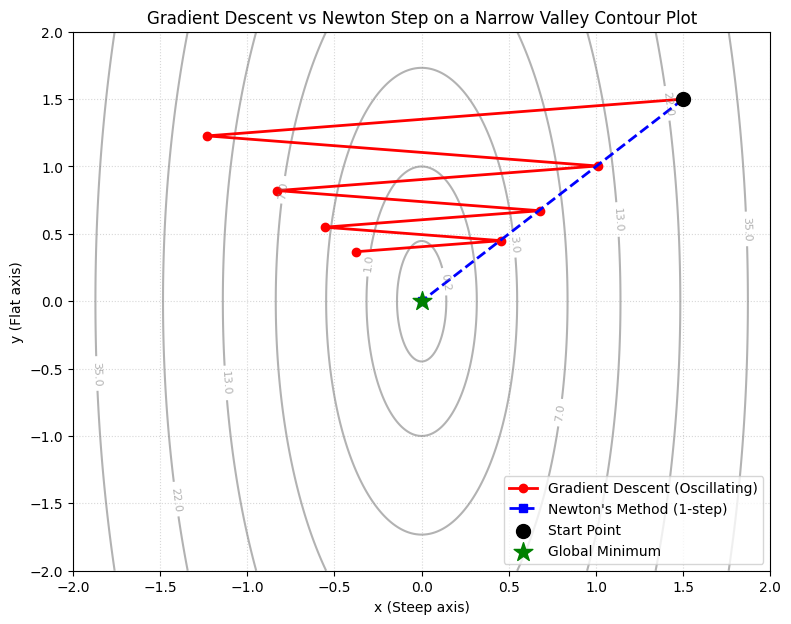

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the objective function and its mathematical components
def f(x, y):
    return 10 * x**2 + y**2  # Elongated valley function

def grad_f(x, y):
    return np.array([20 * x, 2 * y])

# Inverse Hessian matrix for our function
# H = [[20, 0], [0, 2]] -> H_inv = [[1/20, 0], [0, 1/2]]
H_inv = np.array([[1/20, 0.0],
                  [0.0, 1/2]])

# 2. Setup paths tracking
start_pt = np.array([1.5, 1.5])

# Simulating Gradient Descent
lr = 0.091  # Step size chosen to expose the valley oscillation
gd_path = [start_pt]
curr_gd = start_pt.copy()
for _ in range(7):
    curr_gd = curr_gd - lr * grad_f(curr_gd[0], curr_gd[1])
    gd_path.append(curr_gd)
gd_path = np.array(gd_path)

# Simulating Newton's Method
newton_path = [start_pt]
# Standard step: - H_inv * gradient
newton_step = -H_inv @ grad_f(start_pt[0], start_pt[1])
newton_path.append(start_pt + newton_step)
newton_path = np.array(newton_path)

# 3. Create the Visualization Map
plt.figure(figsize=(9, 7))
x_vals = np.linspace(-2.0, 2.0, 400)
y_vals = np.linspace(-2.0, 2.0, 400)
X, Y = np.meshgrid(x_vals, y_vals)
Z = f(X, Y)

# Draw background contours
contours = plt.contour(X, Y, Z, levels=[0.2, 1, 3, 7, 13, 22, 35], colors='gray', alpha=0.6)
plt.clabel(contours, inline=True, fontsize=8)

# Plot trajectories
plt.plot(gd_path[:, 0], gd_path[:, 1], color='red', marker='o',
         linewidth=2, label='Gradient Descent (Oscillating)')
plt.plot(newton_path[:, 0], newton_path[:, 1], color='blue', marker='s',
         linewidth=2, linestyle='--', label="Newton's Method (1-step)")

# Label special points
plt.scatter(start_pt[0], start_pt[1], color='black', s=100, zorder=5, label='Start Point')
plt.scatter(0, 0, color='green', marker='*', s=200, zorder=5, label='Global Minimum')

# Context and styling
plt.title('Gradient Descent vs Newton Step on a Narrow Valley Contour Plot')
plt.xlabel('x (Steep axis)')
plt.ylabel('y (Flat axis)')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend()
plt.xlim(-2.0, 2.0)
plt.ylim(-2.0, 2.0)
plt.show()
